In [1]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
from fastfeedback import *

In [2]:
#Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum_weighted.root")

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


In [3]:
#Preparing the data with the default settings, of the current reco performances
def plot_data(method):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    print(f"Direction: {direc_reco.name}")
    print(f"Energy: {energy_reco.name}")
    print(f"Flavor: {flavor_disc.name}")
    print(f"Nu-nubar: {nunubar_disc.name}")

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    #Defining the binning for the true and reco energy and coszenith
    Ebins = np.logspace(-1, 1, 200)
    Czbins = np.linspace(-1, 1, 100)
    Ebins_reco = np.logspace(-1, 1, 50)
    Czbins_reco = np.linspace(-1, 1, 20)

    #Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    null_hyps = [
    get_nufit(MH.Normal),
    get_nufit(MH.Normal),
    get_nufit(MH.Inverted),
    get_nufit(MH.Inverted)
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi/2
    null_hyps[2].dcp = 0
    null_hyps[3].dcp = np.pi/2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append({fl: events.detected_events(fl) for fl in events.detected_channels})

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(MH.Normal)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i, null_hyp in enumerate(null_hyps):
            #Computing the LnL values
            llh = 0
            for ch in events.detected_channels:
                llh += LnL(ref_event_rates[i][ch], expected[ch])
            LnL_values_nofit[i].append(llh)
        
    fig, ax = plt.subplots()
    ax.plot(dcp_scan, LnL_values_nofit[0], label="NH, dcp=0")
    ax.plot(dcp_scan, LnL_values_nofit[1], label="NH, dcp=π/2")
    ax.plot(dcp_scan, LnL_values_nofit[2], label="IH, dcp=0")
    ax.plot(dcp_scan, LnL_values_nofit[3], label="IH, dcp=π/2")

    ax.set_xlabel(r"$\delta_{CP}$")
    ax.set_ylabel("Log likelihood")
    ax.set_title(f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}")
    plt.legend()
    plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]

Direction: Reco
Energy: Reco
Flavor: Reco
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


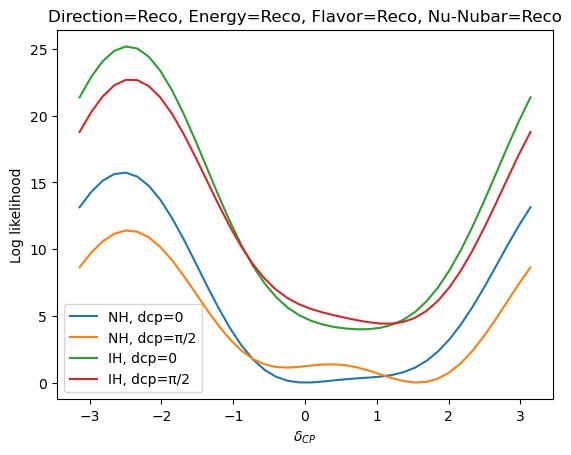

  6%|▋         | 1/16 [00:28<07:09, 28.65s/it]

Direction: Truth
Energy: Reco
Flavor: Reco
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


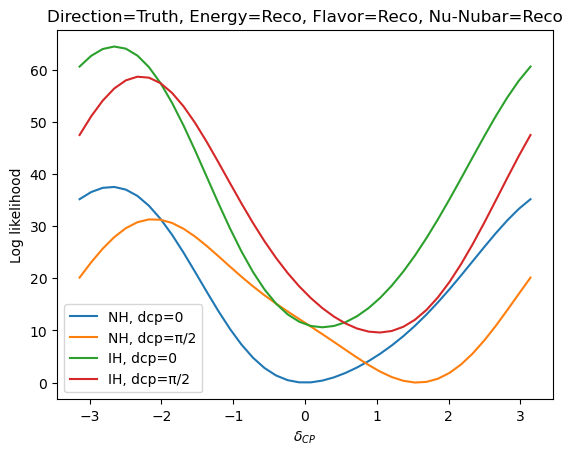

 12%|█▎        | 2/16 [00:50<05:47, 24.81s/it]

Direction: Reco
Energy: Truth
Flavor: Reco
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


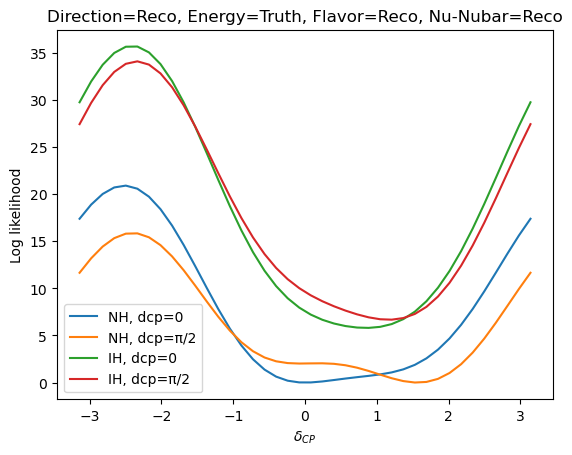

 19%|█▉        | 3/16 [01:15<05:20, 24.65s/it]

Direction: Truth
Energy: Truth
Flavor: Reco
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


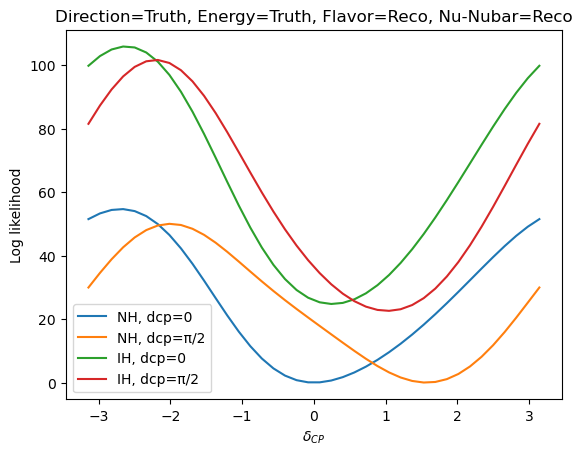

 25%|██▌       | 4/16 [01:33<04:27, 22.29s/it]

Direction: Reco
Energy: Reco
Flavor: Truth
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


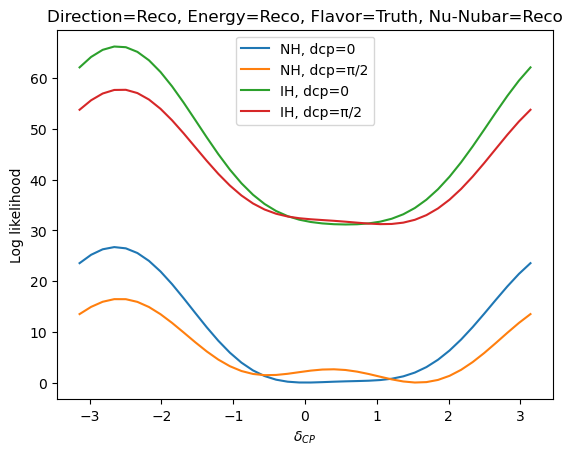

 31%|███▏      | 5/16 [02:11<05:06, 27.90s/it]

Direction: Truth
Energy: Reco
Flavor: Truth
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


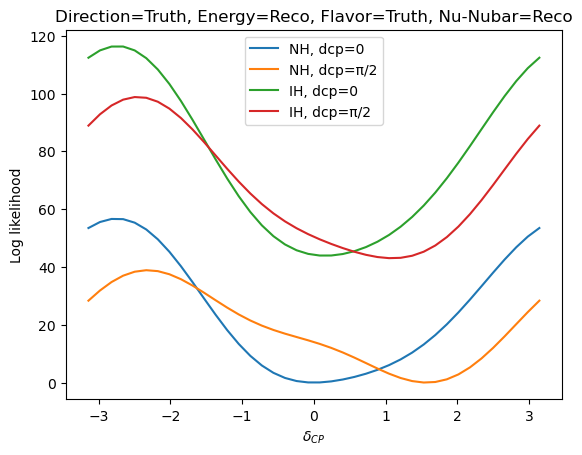

 38%|███▊      | 6/16 [02:46<05:00, 30.10s/it]

Direction: Reco
Energy: Truth
Flavor: Truth
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


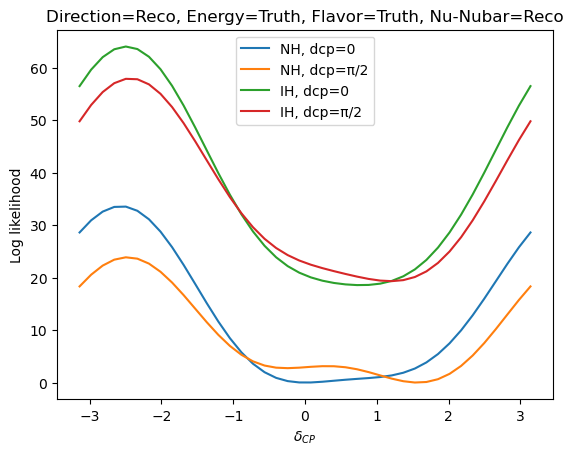

 44%|████▍     | 7/16 [03:22<04:48, 32.08s/it]

Direction: Truth
Energy: Truth
Flavor: Truth
Nu-nubar: Reco
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


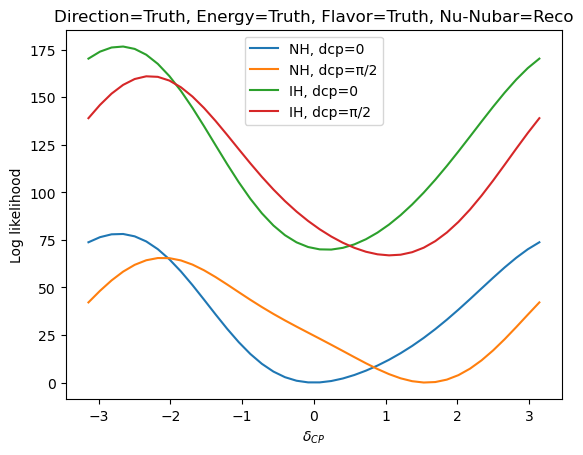

 50%|█████     | 8/16 [03:52<04:12, 31.61s/it]

Direction: Reco
Energy: Reco
Flavor: Reco
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


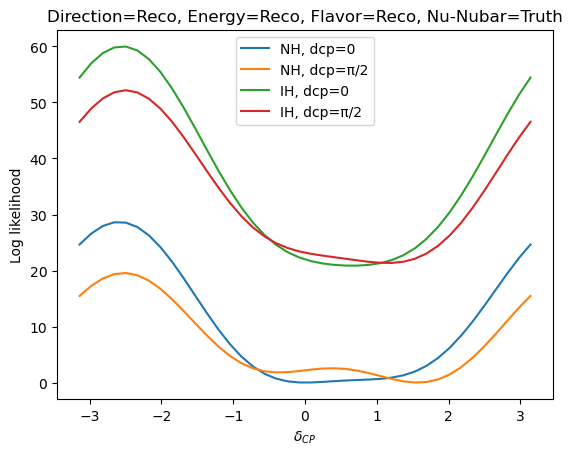

 56%|█████▋    | 9/16 [04:26<03:46, 32.37s/it]

Direction: Truth
Energy: Reco
Flavor: Reco
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


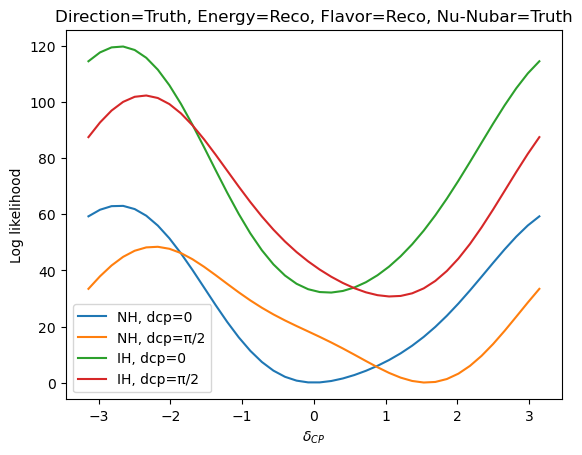

 62%|██████▎   | 10/16 [04:57<03:11, 31.84s/it]

Direction: Reco
Energy: Truth
Flavor: Reco
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


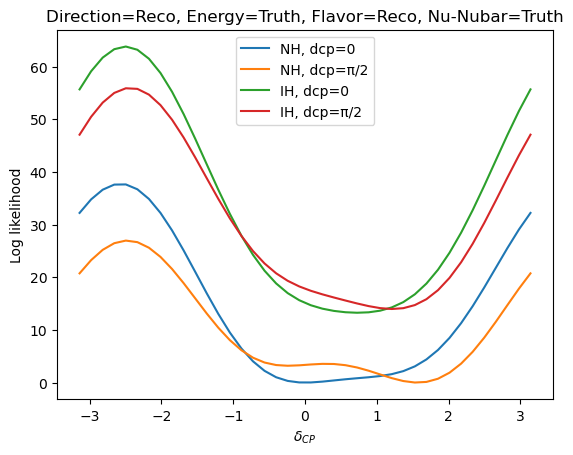

 69%|██████▉   | 11/16 [05:30<02:41, 32.30s/it]

Direction: Truth
Energy: Truth
Flavor: Reco
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


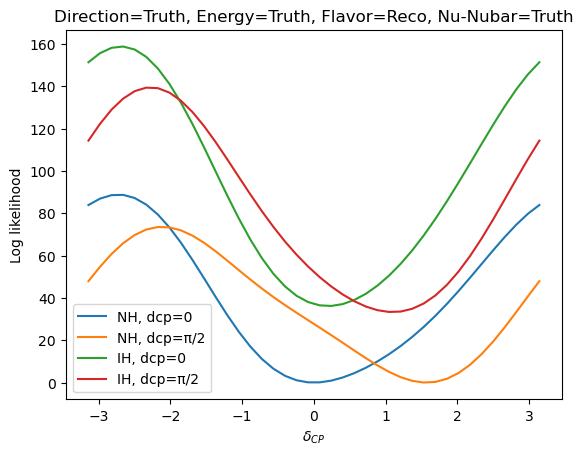

 75%|███████▌  | 12/16 [05:58<02:03, 30.85s/it]

Direction: Reco
Energy: Reco
Flavor: Truth
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


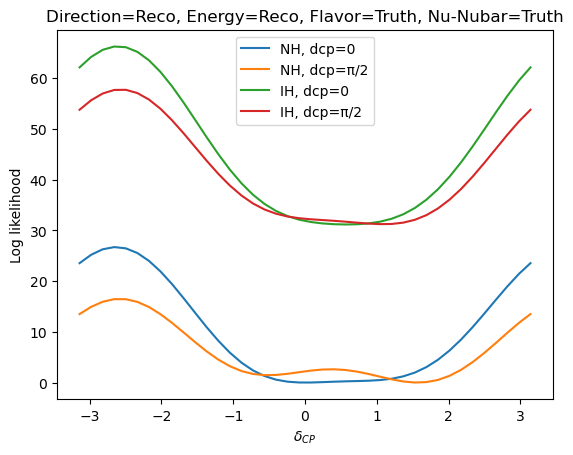

 81%|████████▏ | 13/16 [06:35<01:38, 32.84s/it]

Direction: Truth
Energy: Reco
Flavor: Truth
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


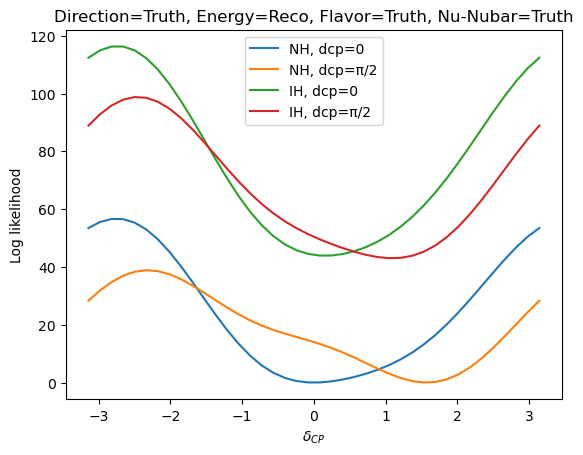

 88%|████████▊ | 14/16 [07:09<01:06, 33.22s/it]

Direction: Reco
Energy: Truth
Flavor: Truth
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


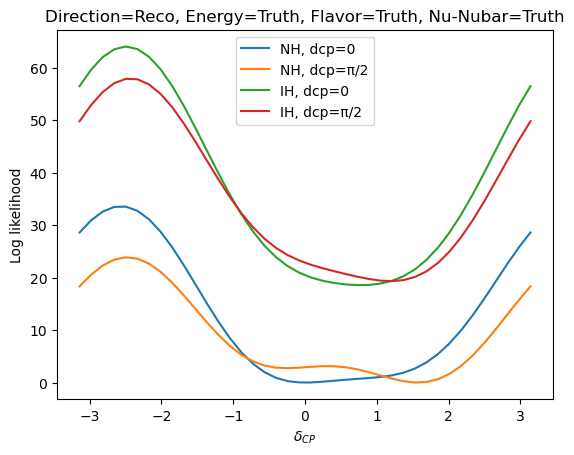

 94%|█████████▍| 15/16 [07:45<00:34, 34.04s/it]

Direction: Truth
Energy: Truth
Flavor: Truth
Nu-nubar: Truth
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


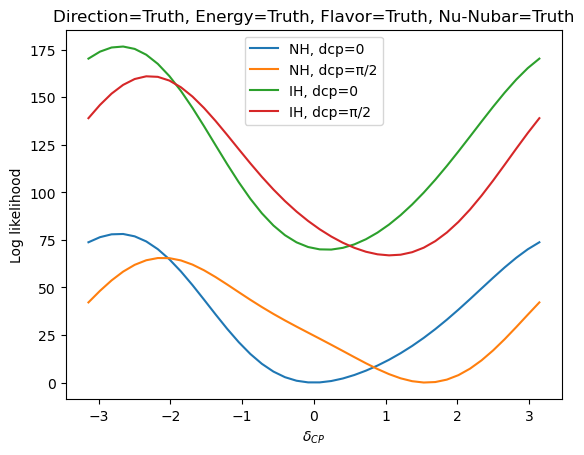

100%|██████████| 16/16 [08:16<00:00, 31.02s/it]


In [4]:
from tqdm import tqdm

for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)
